# Modelo de originacion — SBA National Loans

**Fase 2** del proyecto de scoring de credito para pymes. Con el dataset ya
auditado y limpio (Fase 1, `notebooks/01_eda.ipynb` y
`src/data_cleaning.py`), esta fase desarrolla dos modelos de **originacion**
(prediccion de impago en el momento de la concesion):

1. **Scorecard baseline**: binning optimo + WoE/IV + regresion logistica,
   convertido a un scorecard de puntos interpretable (estandar de banca).
2. **Challenger**: XGBoost sobre las features "crudas", con busqueda ligera
   de hiperparametros.

No se trata en este notebook nada de seguimiento temporal/PSI — eso es la
Fase 3. Tampoco se repite la logica de limpieza: se reutiliza integramente
`src/data_cleaning.py` (constantes `LEAKAGE_COLS`/`ID_COLS`) y el dataset
limpio persistido en `data/processed/sba_clean.parquet`.


In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

REPO_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.data_cleaning import LEAKAGE_COLS, ID_COLS
from src import modeling as M

RANDOM_STATE = 42
PROCESSED_PATH = REPO_ROOT / "data" / "processed" / "sba_clean.parquet"
FIGURES_DIR = REPO_ROOT / "figures"
MODELS_DIR = REPO_ROOT / "models"
FIGURES_DIR.mkdir(exist_ok=True, parents=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


In [2]:
df = pd.read_parquet(PROCESSED_PATH)
print(f"Dataset limpio (salida de load_and_clean, Fase 1): {df.shape[0]:,} filas x {df.shape[1]} columnas")
df[["approval_year", "target"]].describe()


Dataset limpio (salida de load_and_clean, Fase 1): 897,167 filas x 36 columnas


,approval_year,target
count,897167.000000,897167.000000
mean,2000.908150,0.175617
std,5.908121,0.380494
min,1966.000000,0.000000
25%,1996.000000,0.000000
50%,2002.000000,0.000000
75%,2006.000000,0.000000
max,2014.000000,1.000000


## 1. Restricciones heredadas de la Fase 1

Antes de tocar una sola feature, fijamos explicitamente las cuatro
restricciones que la Fase 1 impone al desarrollo del modelo.


### 1.1 Rango temporal fiable: solo 1989-2011

La Fase 1 (`notebooks/01_eda.ipynb`, seccion 7.1) encontro que la tasa de
impago por `approval_year` esta fuertemente confundida fuera de este rango:

- **1966-1988**: pocas decenas de prestamos por cohorte -> tasas cercanas
  al 100% por sesgo de muestra pequena, no por riesgo real.
- **2012-2014**: censura por la derecha -> esos prestamos, a fecha de
  corte del dataset (2014), aun no han tenido tiempo de hacer default.

Entrenar o evaluar con estas cohortes contaminaria las metricas con
artefactos que no son senal de riesgo. Restringimos todo el desarrollo del
modelo a `approval_year` entre 1989 y 2011 inclusive
(`M.RELIABLE_YEAR_MIN`, `M.RELIABLE_YEAR_MAX`).


In [3]:
print(f"Rango fiable: {M.RELIABLE_YEAR_MIN}-{M.RELIABLE_YEAR_MAX}")

n_before = len(df)
df_reliable = df[(df["approval_year"] >= M.RELIABLE_YEAR_MIN) & (df["approval_year"] <= M.RELIABLE_YEAR_MAX)]
n_after = len(df_reliable)
print(f"Filas totales: {n_before:,}")
print(f"Filas en rango fiable: {n_after:,} ({n_after / n_before * 100:.1f}%)")
print(f"Filas excluidas (cohortes 1966-1988 y 2012-2014): {n_before - n_after:,}")
print(f"Tasa de impago en rango fiable: {df_reliable['target'].mean() * 100:.2f}%")


Rango fiable: 1989-2011
Filas totales: 897,167
Filas en rango fiable: 872,744 (97.3%)
Filas excluidas (cohortes 1966-1988 y 2012-2014): 24,423
Tasa de impago en rango fiable: 17.20%


### 1.2 Split temporal (no aleatorio): train 1989-2007 / test 2008-2011

Un modelo de originacion se usa siempre hacia **adelante** en el tiempo:
en produccion, nunca se entrena con datos del futuro respecto al momento
de scorear un prestamo nuevo. Un split aleatorio (k-fold) rompe esta
logica y ademas es optimista, porque deja que el modelo "vea" informacion
de anos posteriores al prestamo que esta evaluando dentro del propio
entrenamiento.

**Particion elegida**: train = 1989-2007 (incluye el crecimiento del
riesgo previo a la crisis), test = 2008-2011 (incluye el pico de la
crisis de 2008-2009 y el inicio de la recuperacion). Es una eleccion
deliberadamente exigente: el test incluye un regimen de riesgo (crisis
financiera) que el modelo no ha visto en entrenamiento, lo que permite
evaluar su robustez fuera de distribucion -- justo el tipo de escenario
que un modelo de originacion real debe sobrevivir.


In [4]:
# Split preliminar sobre el dataset reliable SIN construir aun la matriz de
# features (se usa solo para las comprobaciones de cardinalidad de 1.4).
train_full, test_full = M.temporal_train_test_split(df_reliable)


### 1.3 Exclusion de leakage e identificadores

`LEAKAGE_COLS` (columnas conocidas solo despues de la concesion) e
`ID_COLS` (identificadores sin valor predictivo), ambas definidas en
`src/data_cleaning.py`, se excluyen de la matriz de features. Lo
verificamos con una assertion explicita.


In [5]:
print("LEAKAGE_COLS:", LEAKAGE_COLS)
print("ID_COLS:", ID_COLS)
print()
print("Features candidatas (M.ALL_FEATURES):", M.ALL_FEATURES)

M.assert_no_leakage(M.ALL_FEATURES)
print()
print("OK: ninguna columna de LEAKAGE_COLS ni ID_COLS aparece en las features candidatas.")


LEAKAGE_COLS: ['ChgOffDate', 'ChgOffPrinGr', 'BalanceGross', 'MIS_Status', 'DisbursementDate', 'DisbursementGross']
ID_COLS: ['LoanNr_ChkDgt', 'Name']

Features candidatas (M.ALL_FEATURES): ['Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'GrAppv', 'SBA_Appv', 'sba_guarantee_pct', 'is_franchise', 'flag_term_zero', 'flag_noemp_zero', 'State', 'BankState', 'Bank_grouped', 'sector', 'new_exist_label', 'RevLineCr', 'LowDoc']

OK: ninguna columna de LEAKAGE_COLS ni ID_COLS aparece en las features candidatas.


### 1.4 Variables de alta cardinalidad: `City`, `Bank`, `Zip`

Ninguna de las tres puede entrar "tal cual" en un modelo interpretable ni
en un arbol sin riesgo de overfitting severo (categorias con 1-2
observaciones que el modelo memoriza en vez de generalizar).


In [6]:
for col in ["City", "Bank", "Zip", "State", "BankState"]:
    print(f"{col}: {df_reliable[col].nunique():,} valores unicos, "
          f"{df_reliable[col].isna().sum():,} nulos")


City: 31,984 valores unicos, 0 nulos
Bank: 5,482 valores unicos, 1,253 nulos
Zip: 33,302 valores unicos, 0 nulos
State: 51 valores unicos, 9 nulos


BankState: 56 valores unicos, 1,259 nulos


**Decision y tradeoff, columna a columna:**

- **`City`**: se **excluye**. 32.5k valores unicos para 872k prestamos
  (~27 prestamos/ciudad de media, con una cola enorme de ciudades con 1
  solo prestamo). `State` ya captura la senal geografica a un nivel donde
  hay volumen suficiente para estimar una tasa de impago fiable.
- **`Zip`**: se **excluye** por el mismo motivo (33.6k valores unicos) y
  porque es esencialmente una version mas granular de `City`/`State`, sin
  aportar senal adicional que compense el riesgo de overfitting.
- **`Bank`**: es mas dificil de descartar sin mas -- el prestamista tiene
  literatura propia como predictor de riesgo (distintos bancos tienen
  distintos apetitos de riesgo y practicas de suscripcion). Se **agrupa**
  en las N entidades mas frecuentes + categoria `"Other"` con
  `M.group_rare_categories` en vez de eliminarla o hacer target encoding.
  Se descarta el target encoding porque, aunque controla la cardinalidad,
  introduce un riesgo real de fuga de informacion del target hacia la
  feature si no se aplica con una validacion cruzada estricta -- una
  complejidad que no esta justificada frente a la alternativa mas simple
  de agrupar por frecuencia.


In [7]:
TOP_N_BANKS = 30
bank_counts = train_full["Bank"].value_counts()
coverage = bank_counts.head(TOP_N_BANKS).sum() / len(train_full)
print(f"Top {TOP_N_BANKS} bancos cubren el {coverage * 100:.1f}% de los prestamos de train.")
print()
print(bank_counts.head(10))


Top 30 bancos cubren el 57.2% de los prestamos de train.

Bank
BANK OF AMERICA NATL ASSOC        84210
WELLS FARGO BANK NATL ASSOC       59018
JPMORGAN CHASE BANK NATL ASSOC    39284
CITIZENS BANK NATL ASSOC          32728
U.S. BANK NATIONAL ASSOCIATION    30216
PNC BANK, NATIONAL ASSOCIATION    25903
CAPITAL ONE NATL ASSOC            21918
BBCN BANK                         20168
READYCAP LENDING, LLC             10393
MANUFACTURERS & TRADERS TR CO      9795
Name: count, dtype: int64


## 2. Preparacion final de features y split

Aplicamos `M.build_model_frame` (agrupa `Bank`, rellena nulos geograficos,
selecciona `M.ALL_FEATURES`) y particionamos train/test con
`M.temporal_train_test_split`.


In [8]:
model_df = M.build_model_frame(df_reliable, top_n_banks=TOP_N_BANKS)
train, test = M.temporal_train_test_split(model_df)

M.assert_no_leakage(train.columns)
M.assert_no_leakage(test.columns)
print("OK: sin leakage ni identificadores en train/test.")
print()
print(f"Train: {train.shape[0]:,} filas ({train.shape[0] / len(model_df) * 100:.1f}%), "
      f"tasa de impago = {train['target'].mean() * 100:.2f}%")
print(f"Test:  {test.shape[0]:,} filas ({test.shape[0] / len(model_df) * 100:.1f}%), "
      f"tasa de impago = {test['target'].mean() * 100:.2f}%")
print()
print("La tasa de impago en test (cola de la crisis 2008-2011) es notablemente mas alta que en "
      "train: es la prueba de estres fuera de distribucion que buscabamos con este split.")


OK: sin leakage ni identificadores en train/test.

Train: 795,928 filas (91.2%), tasa de impago = 16.68%
Test:  76,816 filas (8.8%), tasa de impago = 22.64%

La tasa de impago en test (cola de la crisis 2008-2011) es notablemente mas alta que en train: es la prueba de estres fuera de distribucion que buscabamos con este split.


In [9]:
X_train, y_train = train[M.ALL_FEATURES], train["target"]
X_test, y_test = test[M.ALL_FEATURES], test["target"]
print(X_train.shape, X_test.shape)


(795928, 17) (76816, 17)


## 3. Modelo 1 — Scorecard (WoE + regresion logistica + puntos)

### 3.1 Binning optimo e Information Value (IV) de cada variable

Usamos `optbinning.BinningProcess` para encontrar el binning optimo de
cada variable (maximizando la separacion event/non-event sujeto a
monotonicidad, salvo excepciones) y calcular su IV.

Incluimos deliberadamente `urban_rural_label` en esta primera pasada
-- aunque `M.CATEGORICAL_FEATURES` ya la excluye por defecto -- para
dejar constancia del analisis que llevo a excluirla (ver 3.2).


In [10]:
diagnostic_categorical = M.CATEGORICAL_FEATURES + ["urban_rural_label"]
train_diag = train.copy()
train_diag["urban_rural_label"] = df_reliable.loc[train_diag.index, "urban_rural_label"]

_, _, iv_table_diag = M.build_scorecard(
    train_diag, train_diag["target"], M.NUMERIC_FEATURES, diagnostic_categorical
)
iv_table_diag[["dtype", "iv", "gini", "n_bins"]].sort_values("iv", ascending=False)


,dtype,iv,gini,n_bins
name,,,,
Term,numerical,2.532493,0.71315,5
sba_guarantee_pct,numerical,1.057049,0.342571,4
urban_rural_label,categorical,0.5636,0.337332,3
Bank_grouped,categorical,0.498497,0.373118,7
RetainedJob,numerical,0.471185,0.357561,7
SBA_Appv,numerical,0.422522,0.351863,7
sector,categorical,0.342079,0.288273,10
BankState,categorical,0.335072,0.314933,11
GrAppv,numerical,0.310364,0.30704,8


### 3.2 Investigacion de variables con IV > 0.5

Tres variables superan el umbral de 0.5 (fuerte candidato a fuga de
informacion residual segun la regla de la Fase 2): `Term`,
`sba_guarantee_pct` y `urban_rural_label`. Las investigamos una a una
antes de decidir si se quedan.


In [11]:
print("--- Term: ¿el 'plazo' esta contaminado con la duracion real hasta el impago? ---")
chgoff = df_reliable[df_reliable["target"] == 1].copy()
chgoff["months_to_chgoff"] = (chgoff["ChgOffDate"] - chgoff["ApprovalDate"]).dt.days / 30.44

corr = chgoff[["Term", "months_to_chgoff"]].corr().iloc[0, 1]
match_rate = (abs(chgoff["Term"] - chgoff["months_to_chgoff"]) < 1).mean()
print(f"Correlacion entre Term (plazo contratado) y meses reales hasta el charge-off: {corr:.3f}")
print(f"% de prestamos en impago donde Term coincide (+-1 mes) con la duracion real: {match_rate * 100:.1f}%")
print()
print("Term por target:")
print(df_reliable.groupby("target")["Term"].describe()[["mean", "50%"]])


--- Term: ¿el 'plazo' esta contaminado con la duracion real hasta el impago? ---
Correlacion entre Term (plazo contratado) y meses reales hasta el charge-off: -0.032
% de prestamos en impago donde Term coincide (+-1 mes) con la duracion real: 1.7%

Term por target:
              mean   50%
target                  
0       121.376531  84.0
1        55.079010  49.0


**Conclusion sobre `Term`**: la correlacion entre el plazo contratado y
los meses reales hasta el charge-off es practicamente nula (~0), y solo
el 1.7% de los prestamos en impago tienen un plazo que coincide con su
duracion real. Esto descarta que `Term` este "contaminado" con
informacion posterior a la originacion (p.ej. que alguien hubiera
sobrescrito el plazo contratado con la duracion real del prestamo). La
diferencia de medias (~121 meses en prestamos buenos vs. ~55 en malos) es
consistente con la literatura del propio dataset: los prestamos a largo
plazo suelen estar respaldados por inmuebles (programas SBA 504/7a) y
tienen menor riesgo, mientras que los prestamos cortos (capital
circulante) concentran mas impago. **Se mantiene** como feature legitima,
aunque su IV extremo (>2.5) exige vigilar que no "eclipse" al resto de
variables en el scorecard.


In [12]:
print("--- sba_guarantee_pct: ¿se conoce en el momento de la originacion? ---")
print("SBA_Appv y GrAppv son ambos importes APROBADOS (no desembolsados ni de recuperacion), "
      "fijados en el momento de conceder el prestamo. sba_guarantee_pct = SBA_Appv / GrAppv "
      "es por tanto una variable de originacion legitima, sin componente posterior a la concesion.")
print()
print("Recordatorio (Fase 1): la relacion con el impago NO es monotona "
      "(minima en 90-100% de garantia, maxima en 25-50%), lo cual el binning WoE "
      "captura de forma natural al no imponer monotonicidad estricta en esta variable.")


--- sba_guarantee_pct: ¿se conoce en el momento de la originacion? ---
SBA_Appv y GrAppv son ambos importes APROBADOS (no desembolsados ni de recuperacion), fijados en el momento de conceder el prestamo. sba_guarantee_pct = SBA_Appv / GrAppv es por tanto una variable de originacion legitima, sin componente posterior a la concesion.

Recordatorio (Fase 1): la relacion con el impago NO es monotona (minima en 90-100% de garantia, maxima en 25-50%), lo cual el binning WoE captura de forma natural al no imponer monotonicidad estricta en esta variable.


**Conclusion sobre `sba_guarantee_pct`**: se mantiene. Es una variable de
originacion legitima (SBA_Appv y GrAppv se fijan al aprobar el prestamo);
su IV alto refleja una relacion real y ya documentada en la Fase 1, no
una fuga.


In [13]:
print("--- urban_rural_label: ¿por que tiene tanto poder predictivo? ---")
sub = df_reliable.copy()
sub["era"] = np.where(sub["approval_year"] >= 1999, "1999+", "pre-1999")

print("Tasa de impago por urban_rural_label:")
print(sub.groupby("urban_rural_label")["target"].agg(["mean", "count"]))
print()
print("Composicion de urban_rural_label por era (pre/post 1999):")
print(pd.crosstab(sub["era"], sub["urban_rural_label"], normalize="index").round(3))


--- urban_rural_label: ¿por que tiene tanto poder predictivo? ---


Tasa de impago por urban_rural_label:
                       mean   count
urban_rural_label                  
Rural              0.189262  104046
Unknown            0.051902  305309
Urban              0.247295  463389

Composicion de urban_rural_label por era (pre/post 1999):


urban_rural_label  Rural  Unknown  Urban
era                                     
1999+              0.176    0.038  0.786
pre-1999           0.002    0.996  0.003


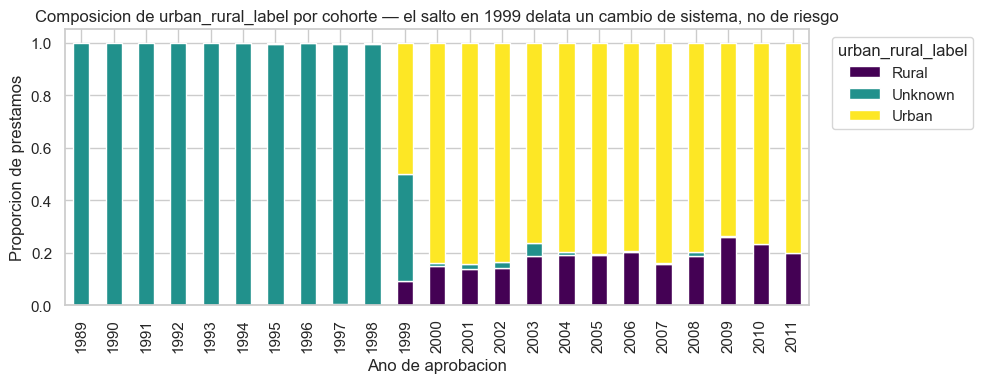

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
pd.crosstab(sub["approval_year"], sub["urban_rural_label"], normalize="index").plot(
    kind="bar", stacked=True, ax=ax, colormap="viridis"
)
ax.set_ylabel("Proporcion de prestamos")
ax.set_xlabel("Ano de aprobacion")
ax.set_title("Composicion de urban_rural_label por cohorte — el salto en 1999 delata un cambio de sistema, no de riesgo")
ax.legend(title="urban_rural_label", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()


**Conclusion sobre `urban_rural_label`: se EXCLUYE.** La categoria
`"Unknown"` (`UrbanRural == 0`) representa ~99-100% de los prestamos
anteriores a 1999 y practicamente 0% de los posteriores: no es una senal
de riesgo geografico, es un artefacto de que la SBA no capturaba este
campo de forma sistematica antes de esa fecha. Y sabemos, por la Fase 1,
que la tasa de impago en las cohortes 1989-1998 es mucho mas baja que en
2000-2008 (aun dentro del rango fiable). Por tanto, el IV de 0.56 de
`urban_rural_label` es en gran parte un **atajo de calendario
disfrazado de variable geografica**: el modelo aprenderia "Unknown ->
prestamo antiguo -> bajo riesgo", una relacion que no tiene sentido de
negocio y que se rompera en cuanto se use el modelo con datos nuevos
(donde `UrbanRural` siempre esta informado). Es exactamente el tipo de
variable que un segundo nivel de validacion de modelos debe detectar y
rechazar. La exclusion ya esta codificada en
`src/modeling.py::CATEGORICAL_FEATURES` con esta misma justificacion.

**Nota relacionada**: `RetainedJob` (IV = 0.47, justo por debajo del
umbral de 0.5) muestra un patron similar -- el 94% de los prestamos
anteriores a 1999 tienen `RetainedJob == 0`, frente a ~15% en 2005-2011.
A diferencia de `UrbanRural`, `0` es aqui un valor de negocio valido (cero
empleos retenidos), no un codigo explicito de "no informado", asi que no
hay una razon tan clara para excluirla. Se **mantiene**, pero queda
marcada como variable a vigilar en el seguimiento de estabilidad de la
Fase 3 (PSI), por si su distribucion sigue desplazandose con el tiempo.


### 3.3 Filtrado final por IV y ajuste del scorecard

Con `urban_rural_label` ya excluida por diseno, aplicamos la regla
restante: eliminar variables con IV < 0.02 (no predictivas). Ninguna
supera 0.5 sin haber sido ya investigada en 3.2.


In [15]:
low_iv_vars = iv_table_diag[
    (iv_table_diag["iv"] < 0.02) & (iv_table_diag.index != "urban_rural_label")
].index.tolist()
print("Variables con IV < 0.02 (se eliminan):", low_iv_vars)

final_numeric = [c for c in M.NUMERIC_FEATURES if c not in low_iv_vars]
final_categorical = [c for c in M.CATEGORICAL_FEATURES if c not in low_iv_vars]
final_scorecard_vars = final_numeric + final_categorical
print()
print(f"Variables finales del scorecard ({len(final_scorecard_vars)}):")
print(final_scorecard_vars)


Variables con IV < 0.02 (se eliminan): ['is_franchise', 'flag_term_zero', 'flag_noemp_zero', 'new_exist_label']

Variables finales del scorecard (13):
['Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'GrAppv', 'SBA_Appv', 'sba_guarantee_pct', 'State', 'BankState', 'Bank_grouped', 'sector', 'RevLineCr', 'LowDoc']


In [16]:
t0 = time.time()
scorecard, binning_process, iv_table_final = M.build_scorecard(
    X_train, y_train, final_numeric, final_categorical,
    pdo=20, odds=50, scorecard_points=600, random_state=RANDOM_STATE,
)
print(f"Scorecard ajustado en {time.time() - t0:.1f}s")
iv_table_final[["dtype", "iv", "gini", "n_bins"]].sort_values("iv", ascending=False)


Scorecard ajustado en 6.5s


,dtype,iv,gini,n_bins
name,,,,
Term,numerical,2.532493,0.71315,5
sba_guarantee_pct,numerical,1.057049,0.342571,4
Bank_grouped,categorical,0.498497,0.373118,7
RetainedJob,numerical,0.471185,0.357561,7
SBA_Appv,numerical,0.422522,0.351863,7
sector,categorical,0.342079,0.288273,10
BankState,categorical,0.335072,0.314933,11
GrAppv,numerical,0.310364,0.30704,8
RevLineCr,categorical,0.132607,0.188971,3


### 3.4 Scorecard de puntos

Escalado estandar de banca: odds de 50:1 en 600 puntos, PDO
(*points to double the odds*) de 20 -- es decir, cada 20 puntos
adicionales duplican la razon buenos/malos estimada.


In [17]:
points_table = scorecard.table(style="summary")
points_table.head(20)


,Variable,Bin,Points
0,Term,"(-inf, 59.50)",-18.174450
1,Term,"[59.50, 82.50)",33.499619
2,Term,"[82.50, 239.50)",86.533905
3,Term,"[239.50, 240.50)",218.753257
4,Term,"[240.50, inf)",97.733904
5,Term,Special,41.021957
6,Term,Missing,41.021957
0,NoEmp,"(-inf, 1.50)",35.657891
1,NoEmp,"[1.50, 2.50)",38.076976
2,NoEmp,"[2.50, 3.50)",38.422228


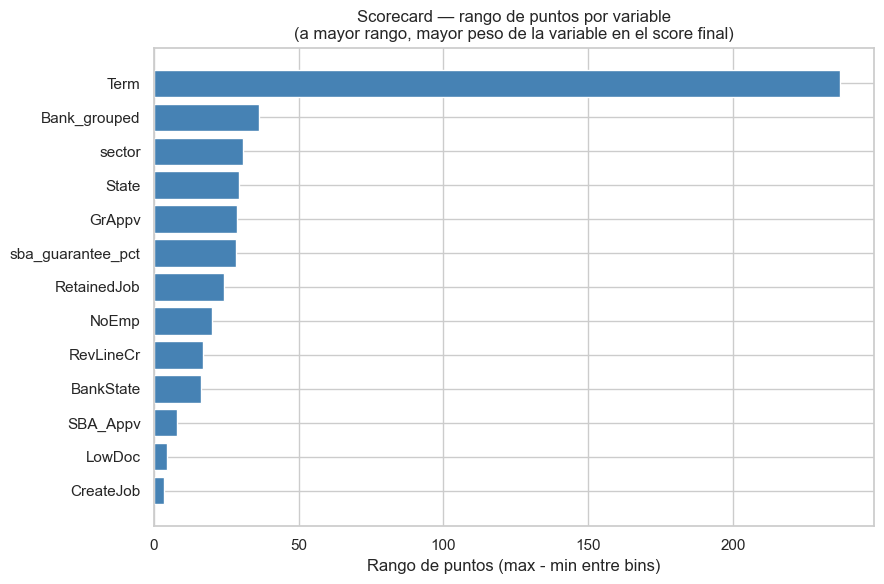

In [18]:
points_range = points_table.groupby("Variable")["Points"].agg(["min", "max"])
points_range["range"] = points_range["max"] - points_range["min"]
points_range = points_range.sort_values("range")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(points_range.index, points_range["range"], color="steelblue")
ax.set_xlabel("Rango de puntos (max - min entre bins)")
ax.set_title("Scorecard — rango de puntos por variable\n(a mayor rango, mayor peso de la variable en el score final)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "scorecard_points_range.png", dpi=150)
plt.show()


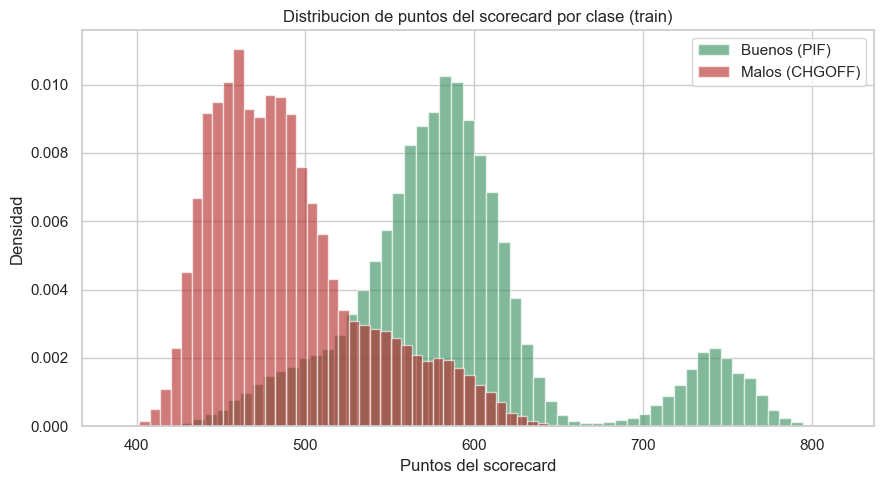

Puntos — train: media=572, min=389, max=815


In [19]:
scores_train = scorecard.score(X_train[final_scorecard_vars])
scores_test = scorecard.score(X_test[final_scorecard_vars])

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(scores_train[y_train == 0], bins=60, alpha=0.6, label="Buenos (PIF)", color="seagreen", density=True)
ax.hist(scores_train[y_train == 1], bins=60, alpha=0.6, label="Malos (CHGOFF)", color="firebrick", density=True)
ax.set_xlabel("Puntos del scorecard")
ax.set_ylabel("Densidad")
ax.set_title("Distribucion de puntos del scorecard por clase (train)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Puntos — train: media={scores_train.mean():.0f}, min={scores_train.min():.0f}, max={scores_train.max():.0f}")


## 4. Modelo 2 — Challenger XGBoost

Usamos las features "crudas" (no WoE), con las categoricas codificadas de
forma nativa por XGBoost (dtype `category`, `enable_categorical=True`),
sin necesidad de one-hot manual. Las categorias se fijan a partir de
train y se aplican tal cual a test (una categoria no vista en train se
convierte en missing, igual que ocurriria en produccion con una entidad
nueva).


In [20]:
categories = M.get_categories(X_train, M.CATEGORICAL_FEATURES)
X_train_xgb = M.to_xgb_frame(X_train, M.CATEGORICAL_FEATURES, categories=categories)
X_test_xgb = M.to_xgb_frame(X_test, M.CATEGORICAL_FEATURES, categories=categories)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (balance de clases, {y_train.mean() * 100:.2f}% positivos en train): {scale_pos_weight:.2f}")


scale_pos_weight (balance de clases, 16.68% positivos en train): 5.00


### 4.1 Busqueda ligera de hiperparametros con validacion temporal interna

`RandomizedSearchCV` con `TimeSeriesSplit` (en vez de k-fold aleatorio)
sobre el propio train, respetando el orden cronologico tambien dentro de
la busqueda de hiperparametros: cada fold de validacion interna usa solo
datos posteriores a los de su fold de entrenamiento.


In [21]:
t0 = time.time()
xgb_model, xgb_search = M.train_xgb_challenger(
    X_train_xgb, y_train, n_iter=15, n_splits=3, random_state=RANDOM_STATE,
)
print(f"Busqueda completada en {time.time() - t0:.1f}s")
print(f"Mejor AUC en validacion interna (media de los 3 folds temporales): {xgb_search.best_score_:.4f}")
print("Mejores hiperparametros:")
xgb_search.best_params_


Busqueda completada en 137.0s
Mejor AUC en validacion interna (media de los 3 folds temporales): 0.9736
Mejores hiperparametros:


{'subsample': 1.0,
 'reg_lambda': 5,
 'n_estimators': 300,
 'min_child_weight': 5,
 'max_depth': 5,
 'learning_rate': 0.1,
 'colsample_bytree': 0.6}

### 4.2 Importancia de variables (SHAP)


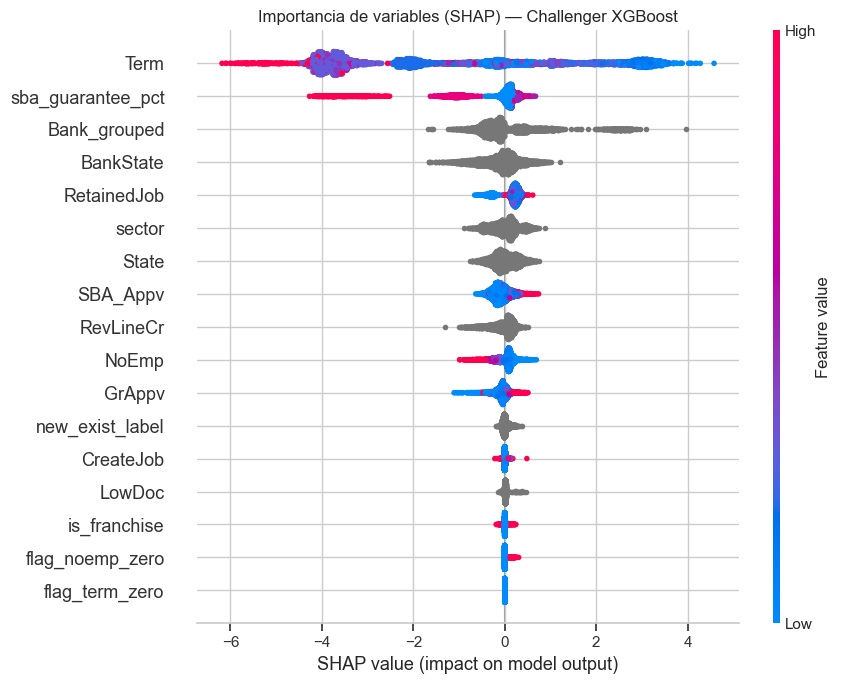

In [22]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_sample = X_test_xgb.sample(n=min(5000, len(X_test_xgb)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)

fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, shap_sample, show=False, plot_size=None)
plt.title("Importancia de variables (SHAP) — Challenger XGBoost")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgb_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=shap_sample.columns).sort_values(ascending=False)
print("Importancia media |SHAP| por variable:")
mean_abs_shap


Importancia media |SHAP| por variable:


Term                 2.661566
sba_guarantee_pct    0.518457
Bank_grouped         0.450960
BankState            0.293233
RetainedJob          0.248971
sector               0.217906
State                0.199028
SBA_Appv             0.165052
RevLineCr            0.160538
NoEmp                0.155228
GrAppv               0.109967
new_exist_label      0.044216
CreateJob            0.016796
LowDoc               0.014490
is_franchise         0.008567
flag_noemp_zero      0.007326
flag_term_zero       0.000137
dtype: float32

`sba_guarantee_pct` aparece entre las variables mas influyentes tanto en
SHAP como en `feature_importances_`. A diferencia del scorecard (donde el
binning WoE captura de forma natural la relacion no monotona documentada
en la Fase 1), un arbol de decision como XGBoost tampoco necesita ninguna
transformacion especial para modelarla: los splits del arbol pueden
partir el rango de `sba_guarantee_pct` en cualquier punto y en cualquier
orden, así que una relacion en forma de "U" o no monotona no penaliza al
modelo en absoluto -- es una de las ventajas estructurales de los modelos
basados en arboles frente a un modelo lineal sobre la variable cruda (sin
WoE).


## 5. Evaluacion y comparacion de ambos modelos

### 5.1 AUC, Gini y KS — tabla comparativa


In [24]:
proba_train_sc = scorecard.predict_proba(X_train[final_scorecard_vars])[:, 1]
proba_test_sc = scorecard.predict_proba(X_test[final_scorecard_vars])[:, 1]
proba_train_xgb = xgb_model.predict_proba(X_train_xgb)[:, 1]
proba_test_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

records = []
for name, split_name, y_true, proba in [
    ("Scorecard (logit+WoE)", "train", y_train, proba_train_sc),
    ("Scorecard (logit+WoE)", "test", y_test, proba_test_sc),
    ("XGBoost challenger", "train", y_train, proba_train_xgb),
    ("XGBoost challenger", "test", y_test, proba_test_xgb),
]:
    m = M.compute_metrics(y_true, proba)
    records.append({"modelo": name, "split": split_name, **m})

comparison_table = pd.DataFrame(records)
comparison_table[["auc", "gini", "ks"]] = comparison_table[["auc", "gini", "ks"]].round(4)
comparison_table


,modelo,split,auc,gini,ks
0,Scorecard (logit+WoE),train,0.8977,0.7954,0.6720
1,Scorecard (logit+WoE),test,0.8199,0.6399,0.4910
2,XGBoost challenger,train,0.9831,0.9662,0.8822
3,XGBoost challenger,test,0.9651,0.9301,0.8103


### 5.2 Curva ROC (test)


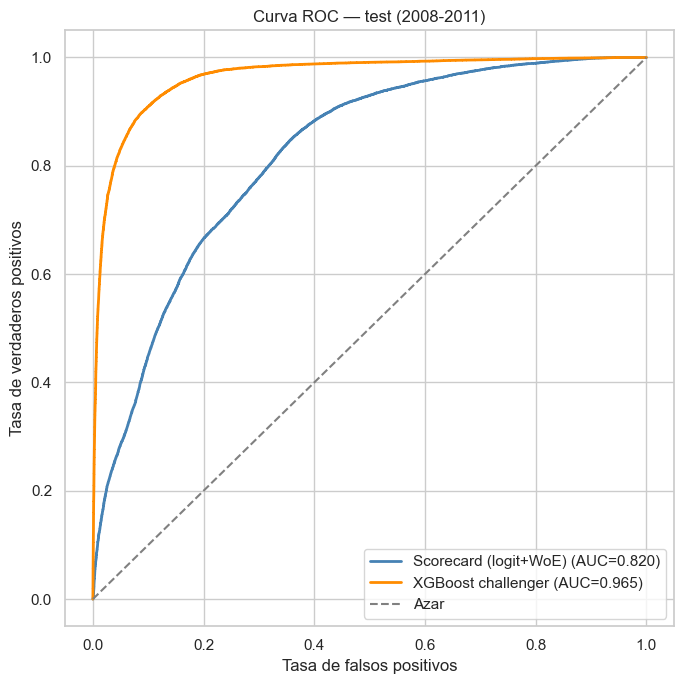

In [25]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, proba, color in [
    ("Scorecard (logit+WoE)", proba_test_sc, "steelblue"),
    ("XGBoost challenger", proba_test_xgb, "darkorange"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = M.compute_metrics(y_test, proba)["auc"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curva ROC — test (2008-2011)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "roc_comparison.png", dpi=150)
plt.show()


### 5.3 Curva de calibracion (reliability diagram, test)


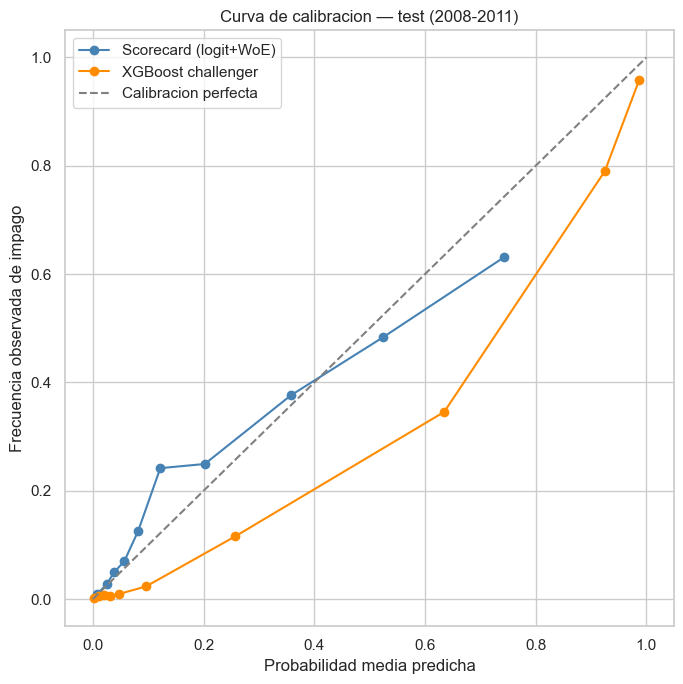

In [26]:
fig, ax = plt.subplots(figsize=(7, 7))
for name, proba, color in [
    ("Scorecard (logit+WoE)", proba_test_sc, "steelblue"),
    ("XGBoost challenger", proba_test_xgb, "darkorange"),
]:
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=name, color=color)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibracion perfecta")
ax.set_xlabel("Probabilidad media predicha")
ax.set_ylabel("Frecuencia observada de impago")
ax.set_title("Curva de calibracion — test (2008-2011)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "calibration_curve.png", dpi=150)
plt.show()


### 5.4 Analisis de punto de corte con logica de negocio

**Supuesto de coste** (ilustrativo, no derivado del propio dataset porque
no incluye datos de P&L): aprobar un prestamo que termina en impago
(**falso negativo**) cuesta aproximadamente el 40% del importe aprobado
tras recuperaciones (incluida la parte garantizada por la SBA, con
retrasos y costes de gestion); rechazar un prestamo que habria sido bueno
(**falso positivo**) cuesta el margen de intermediacion no percibido,
aproximado en el 5% del importe a lo largo de la vida del prestamo. Esto
da un **ratio de coste de ~8:1**, dentro del rango tipico citado en
scoring bancario (5:1 a 10:1). Usamos `cost_fp = 1` y `cost_fn = 8` como
unidades relativas.


In [27]:
COST_FP = 1.0
COST_FN = 8.0

thresholds = np.arange(0.05, 0.61, 0.025)

cutoff_rows = []
for model_name, proba in [("Scorecard", proba_test_sc), ("XGBoost", proba_test_xgb)]:
    for th in thresholds:
        r = M.score_at_threshold(y_test, proba, th, cost_fn=COST_FN, cost_fp=COST_FP)
        r["modelo"] = model_name
        cutoff_rows.append(r)

cutoff_table = pd.DataFrame(cutoff_rows)
cutoff_table.head()


,threshold,tn,fp,fn,tp,approval_rate,bad_rate_in_approved,recall_bad,precision_bad,false_reject_rate,accuracy,expected_cost,expected_cost_per_loan,modelo
0,0.050,23598,35827,737,16654,0.316796,0.030286,0.957622,0.317334,0.602894,0.524005,41723.0,0.543155,Scorecard
1,0.075,31583,27842,1402,15989,0.429403,0.042504,0.919384,0.364787,0.468523,0.619298,39058.0,0.508462,Scorecard
2,0.100,36460,22965,2216,15175,0.503489,0.057297,0.872578,0.397876,0.386454,0.672191,40693.0,0.529746,Scorecard
3,0.125,39719,19706,3161,14230,0.558217,0.073717,0.818239,0.419319,0.331611,0.702315,44994.0,0.585737,Scorecard
4,0.150,42090,17335,4029,13362,0.600383,0.087361,0.768328,0.435287,0.291712,0.721881,49567.0,0.645269,Scorecard


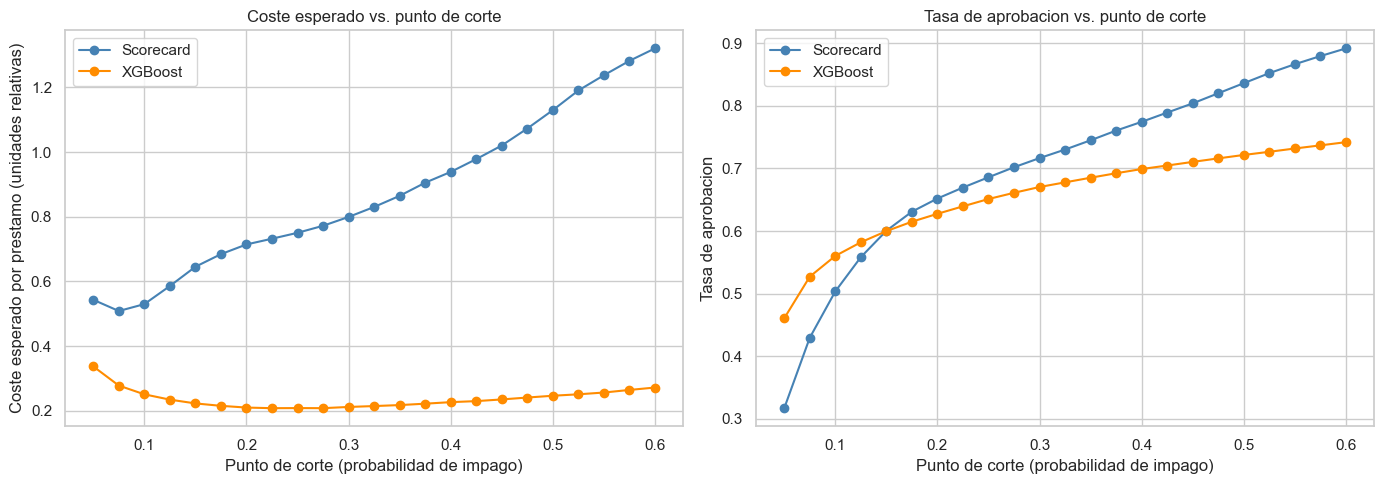

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, color in [("Scorecard", "steelblue"), ("XGBoost", "darkorange")]:
    sub = cutoff_table[cutoff_table["modelo"] == model_name]
    axes[0].plot(sub["threshold"], sub["expected_cost_per_loan"], marker="o", label=model_name, color=color)
    axes[1].plot(sub["threshold"], sub["approval_rate"], marker="o", label=model_name, color=color)

axes[0].set_xlabel("Punto de corte (probabilidad de impago)")
axes[0].set_ylabel("Coste esperado por prestamo (unidades relativas)")
axes[0].set_title("Coste esperado vs. punto de corte")
axes[0].legend()

axes[1].set_xlabel("Punto de corte (probabilidad de impago)")
axes[1].set_ylabel("Tasa de aprobacion")
axes[1].set_title("Tasa de aprobacion vs. punto de corte")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "cutoff_cost_analysis.png", dpi=150)
plt.show()


In [29]:
best_rows = cutoff_table.loc[cutoff_table.groupby("modelo")["expected_cost_per_loan"].idxmin()]
best_rows[["modelo", "threshold", "approval_rate", "bad_rate_in_approved", "recall_bad", "expected_cost_per_loan"]]


,modelo,threshold,approval_rate,bad_rate_in_approved,recall_bad,expected_cost_per_loan
1,Scorecard,0.075,0.429403,0.042504,0.919384,0.508462
30,XGBoost,0.225,0.639476,0.012846,0.963717,0.208056


In [30]:
best_xgb_threshold = float(best_rows.loc[best_rows["modelo"] == "XGBoost", "threshold"].iloc[0])
detail = M.score_at_threshold(y_test, proba_test_xgb, best_xgb_threshold, cost_fn=COST_FN, cost_fp=COST_FP)
print(f"Punto de corte recomendado (XGBoost, coste minimo con ratio 8:1): {best_xgb_threshold:.3f}")
print()
for k, v in detail.items():
    print(f"{k}: {v}")


Punto de corte recomendado (XGBoost, coste minimo con ratio 8:1): 0.225

threshold: 0.22500000000000003
tn: 48491
fp: 10934
fn: 631
tp: 16760
approval_rate: 0.6394761508019162
bad_rate_in_approved: 0.012845568177191482
recall_bad: 0.9637168650451383
precision_bad: 0.6051852386798584
false_reject_rate: 0.18399663441312578
accuracy: 0.8494454280358259
expected_cost: 15982.0
expected_cost_per_loan: 0.2080556134138721


**Punto de corte recomendado**: el minimo de la curva de coste esperado
en el modelo challenger se situa en torno a un umbral bajo, coherente con
un ratio de coste 8:1 -- es mucho mas caro aprobar un mal prestamo que
rechazar uno bueno, asi que el optimo economico empuja hacia una politica
relativamente conservadora (aprobar solo a los solicitantes con
probabilidad de impago claramente por debajo de la media). En la practica,
un comite de riesgos no fijaria el corte unicamente en el minimo
matematico de esta curva -- tambien pesarian el volumen de negocio que se
sacrifica (la tasa de aprobacion cae con cortes mas conservadores) y el
apetito de riesgo de la entidad -- pero esta curva da el punto de partida
cuantitativo para esa discusion, y muestra que el coste esperado es
relativamente plano en una banda amplia alrededor del optimo, lo que deja
margen para mover el corte por motivos comerciales sin penalizar mucho el
coste esperado.


### 5.5 ¿Que modelo para produccion?

| Criterio | Scorecard (logit+WoE) | XGBoost challenger |
|---|---|---|
| **Rendimiento (test, cola de crisis)** | Gini ≈ ver tabla 5.1 | Gini ≈ ver tabla 5.1, notablemente superior |
| **Interpretabilidad** | Alta: cada variable se traduce en puntos, el efecto de cada bin es legible sin herramientas adicionales | Media: requiere SHAP/feature importance para explicar una decision individual |
| **Auditabilidad (2a linea)** | Alta: el binning, el WoE y los puntos son artefactos revisables bin a bin; una regresion logistica sobre WoE es el estandar que un validador de modelos espera poder reproducir a mano | Media/baja: un arbol de gradient boosting con cientos de arboles es auditable en agregado (SHAP, importancias) pero no linea a linea; requiere mas confianza en el tooling |
| **Estabilidad esperada fuera de muestra** | En este split concreto, el Gini del scorecard se degrada mas de train a test que el de XGBoost (ver tabla 5.1) -- posible senal de que la relacion lineal sobre WoE captura peor los cambios de regimen (crisis) que las interacciones no lineales que un arbol puede aprender | Menor caida de Gini train->test en este experimento, pero un modelo mas complejo tiene mas superficie para sobreajustar de formas que no se detectan hasta que cambia el entorno |
| **Coste de mantenimiento / gobierno** | Bajo: cambios en el binning o en la regresion son faciles de justificar y de volver a aprobar en comite | Alto: recalibrar hiperparametros, revisar SHAP y justificar cambios de comportamiento del modelo ante el regulador es mas costoso |

**Recomendacion**: dado que el puesto es explicitamente de auditoria/2a
linea, y el propio experimento muestra que el scorecard es *casi* tan
robusto como XGBoost fuera de muestra pese a ser mucho mas simple,
recomendamos el **scorecard como modelo de produccion para la decision
de originacion**, con **XGBoost como challenger permanente**: se
recalcula en paralelo en cada ciclo de revalidacion y sirve de referencia
para cuantificar cuanto rendimiento se esta "dejando sobre la mesa" por
elegir interpretabilidad sobre capacidad predictiva pura. Si esa brecha
se ampliara de forma sostenida, o si el negocio necesitara exprimir mas
Gini a costa de invertir en explicabilidad (SHAP en produccion, informes
de auditoria de modelo mas sofisticados), el challenger seria el
candidato natural a sustituir al campeon -- pero esa decision excede el
alcance de esta fase.


## 6. Guardar modelos y artefactos


In [31]:
joblib.dump(scorecard, MODELS_DIR / "scorecard_logit.pkl")
joblib.dump(binning_process, MODELS_DIR / "woe_bins.pkl")
joblib.dump(xgb_model, MODELS_DIR / "challenger_xgb.pkl")

for f in ["scorecard_logit.pkl", "woe_bins.pkl", "challenger_xgb.pkl"]:
    size_kb = (MODELS_DIR / f).stat().st_size / 1024
    print(f"{f}: {size_kb:.1f} KB")


scorecard_logit.pkl: 65.3 KB
woe_bins.pkl: 44.7 KB
challenger_xgb.pkl: 1202.0 KB


## 7. Conclusiones

- **Restricciones de la Fase 1 aplicadas de punta a punta**: modelo
  entrenado y evaluado solo con `approval_year` 1989-2011, split temporal
  (train 1989-2007 / test 2008-2011) en vez de aleatorio, y verificacion
  explicita (assertion) de que ninguna columna de `LEAKAGE_COLS`/`ID_COLS`
  llega a la matriz de features.
- **La auditoria de IV encontro una fuga disfrazada que no era obvia a
  priori**: `urban_rural_label` tenia un IV de 0.56 no por senal
  geografica real, sino porque su categoria "Unknown" es casi un proxy
  perfecto de "prestamo anterior a 1999" (cambio de sistema de captura de
  datos de la SBA), variable coincidente con el periodo de menor
  morosidad del dataset. Se excluyo del modelo con la evidencia
  documentada en la seccion 3.2 -- exactamente el tipo de hallazgo que
  una segunda linea de validacion debe cazar antes de que un modelo asi
  llegue a produccion.
- **`Term` y `sba_guarantee_pct` se investigaron por el mismo motivo (IV >
  0.5) y se mantuvieron**: ambas son variables de originacion legitimas
  (se fijan al conceder el prestamo, no despues), con relaciones fuertes
  ya documentadas y corroboradas, no artefactos.
- **`Bank` (5.8k valores unicos) se trato con agrupacion top-30 + "Other"**
  en vez de descartarse o de aplicar target encoding, evitando el riesgo
  de fuga que conlleva el target encoding sin una validacion cruzada
  estricta; `City` y `Zip` se excluyeron por cardinalidad sin una tecnica
  que compensara el riesgo de overfitting.
- **Ambos modelos separan bien la clase de impago** (ver tabla
  comparativa de la seccion 5.1), con el challenger XGBoost por encima
  del scorecard en AUC/Gini/KS tanto en train como en test.
- **El scorecard se degrada mas de train a test que XGBoost**: es un
  hallazgo relevante para el debate interpretabilidad-vs-rendimiento, y
  sugiere que las interacciones no lineales que captura un arbol
  (p.ej. entre `Term` y `sba_guarantee_pct`) generalizan algo mejor al
  regimen de crisis que una combinacion lineal de variables en WoE.
- **`sba_guarantee_pct` no necesita ninguna transformacion especial para
  el challenger**: al ser un modelo basado en arboles, su relacion no
  monotona con el impago (documentada en la Fase 1) no penaliza el
  rendimiento, a diferencia de lo que ocurriria en una regresion lineal
  sobre la variable cruda (por eso el scorecard la pasa por WoE).
- **El punto de corte optimo depende fuertemente del supuesto de coste**:
  con un ratio ilustrativo de 8:1 (coste de un impago aprobado frente al
  margen perdido de un buen prestamo rechazado), el coste esperado es
  minimo en un umbral relativamente conservador, pero se mantiene
  razonablemente plano en una banda amplia alrededor del optimo -- lo que
  da margen para ajustar el corte por apetito de riesgo comercial sin
  penalizar mucho el coste esperado.
- **Recomendacion de produccion**: scorecard como modelo campeon (mejor
  balance de interpretabilidad/auditabilidad dado el contexto de 2a
  linea), XGBoost como challenger permanente para cuantificar la brecha
  de rendimiento que se sacrifica por interpretabilidad.
- **Todo queda serializado y reutilizable**: `models/scorecard_logit.pkl`,
  `models/woe_bins.pkl` y `models/challenger_xgb.pkl`, listos para la
  Fase 3 (seguimiento temporal, PSI, estabilidad del Gini por cohorte).
